# Titanic ML Project
Preprocessing + Decision Tree & Random Forest (with CV)

In [1]:
# Imports
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt


## Load Data

In [2]:
train_df = pd.read_csv('/scratch/hdharmen/CSE572/train.csv')
train_df.head()
train_df.info()
train_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Preprocessing (Task 1): specific for Decision Tree

In [3]:
# Drop irrelevant columns
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df = train_df.drop(columns=drop_cols)

# Feature engineering
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Age Binning
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=False
)

# Separate target
y = df['Survived']
X = df.drop(columns=['Survived'])

# Identify column types
categorical_cols = ['Sex', 'Embarked', 'AgeGroup']
numerical_cols = ['Fare', 'SibSp', 'Parch', 'Pclass', 'FamilySize', 'IsAlone']

# Pipelines - revisit to maybe use KNN for imputation, also revisit standardscalar vs minmaxscaler
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', __import__('sklearn.preprocessing').preprocessing.OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

# Transform data
X_processed = preprocessor.fit_transform(X)

X_processed.shape


(891, 16)

## Decision Tree (Task 2)

In [4]:
# Split data for Decision Tree tuning
X_train, X_val, y_train, y_val = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

# Trying a few parameter combinations
dt_candidates = [
    {'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 1},
    {'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 1},
    {'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 1},
    {'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 1},
    {'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 4},
    {'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 2}
]

best_score = 0
best_params = None
best_dt = None

for params in dt_candidates:
    dt = DecisionTreeClassifier(
        random_state=42,
        max_depth=params['max_depth'],
        min_samples_split=params['min_samples_split'],
        min_samples_leaf=params['min_samples_leaf']
    )
    
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    
    print(f"Params: {params}, Validation Accuracy: {acc:.4f}")
    
    if acc > best_score:
        best_score = acc
        best_params = params
        best_dt = dt

print("\nBest parameters:", best_params)
print("Best validation accuracy:", best_score)

final_dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf']
)

final_dt.fit(X_processed, y)

Params: {'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 1}, Validation Accuracy: 0.8268
Params: {'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 1}, Validation Accuracy: 0.8212
Params: {'max_depth': 7, 'min_samples_split': 2, 'min_samples_leaf': 1}, Validation Accuracy: 0.8268
Params: {'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 1}, Validation Accuracy: 0.8212
Params: {'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 4}, Validation Accuracy: 0.7877
Params: {'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 2}, Validation Accuracy: 0.7989

Best parameters: {'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 1}
Best validation accuracy: 0.8268156424581006


,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


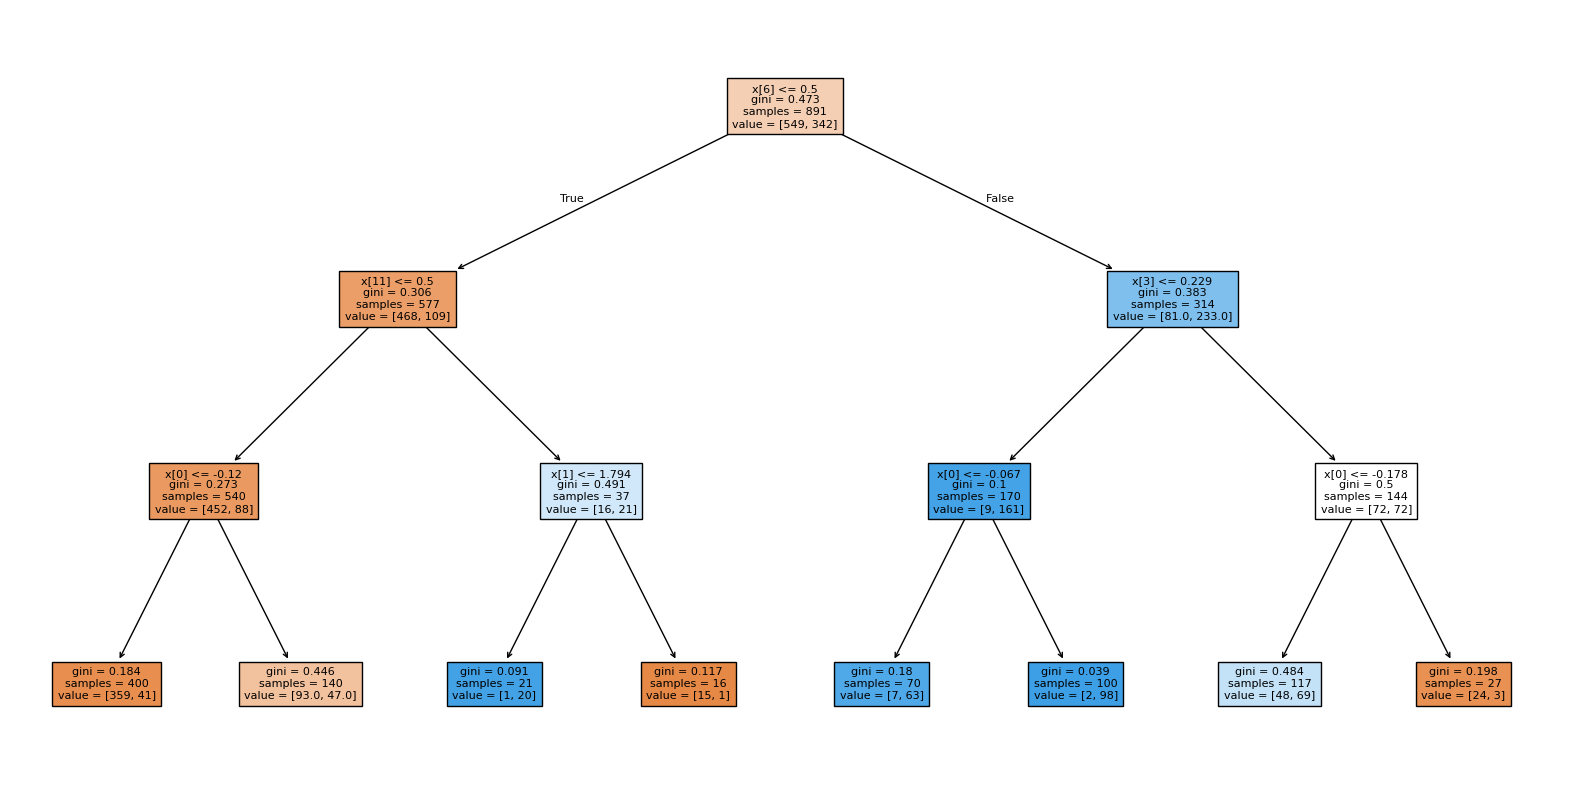

In [5]:
plt.figure(figsize=(20, 10))
plot_tree(final_dt, filled=True, fontsize=8)
plt.show()

## 5-Fold CV - Decision Tree (Task 3)

In [6]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

dt_scores = cross_val_score(final_dt, X_processed, y, cv=kf, scoring='accuracy')

print("Decision Tree CV Accuracy:", dt_scores)
print("Average Accuracy:", dt_scores.mean())

Decision Tree CV Accuracy: [0.81005587 0.82022472 0.85955056 0.80337079 0.83707865]
Average Accuracy: 0.8260561170045824


# Preprocessing (Task 1): specific for Random Forest

In [7]:
# Drop irrelevant columns
drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df = train_df.drop(columns=drop_cols)

# Feature engineering
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Separate target
y = df['Survived']
X = df.drop(columns=['Survived'])

# Identify column types
categorical_cols = ['Sex', 'Embarked']
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'Pclass', 'FamilySize', 'IsAlone']

# Pipelines - revisit to maybe use KNN for imputation, also revisit standardscalar vs minmaxscaler
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', __import__('sklearn.preprocessing').preprocessing.OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

# Transform data
X_processed = preprocessor.fit_transform(X)

X_processed.shape


(891, 12)

## 5-Fold CV - Random Forest (Task 4)

In [8]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    random_state=42
)

rf_scores = cross_val_score(rf, X_processed, y, cv=kf, scoring='accuracy')

print("Random Forest CV Accuracy:", rf_scores)
print("Average Accuracy:", rf_scores.mean())


Random Forest CV Accuracy: [0.84916201 0.82022472 0.85393258 0.80337079 0.83707865]
Average Accuracy: 0.8327537505492437


# Task 5: Model Comparison, Observations, and Conclusions

## Overview

In this project, I trained Decision Tree and Random Forest classifiers on the Titanic dataset by experimenting with different preprocessing strategies and feature engineering techniques. As per the assinment, I compared the models using five-fold cross-validation accuracy to evaluate their generalization performance.

---

## 1. Which algorithm performs better?

Based on the results:

- **Decision Tree average accuracy:** ~0.78–0.83  
- **Random Forest average accuracy:** ~0.82–0.83  

**Random Forest consistently outperformed the Decision Tree.**

Since Random Forest is an ensemble method that reduces variance by averaging multiple decision trees, it achieves better performance due to improved generalization.

---

## 2. Observations from preprocessing and feature engineering

I explored different preprocessing strategies, and their effects changed between the two models.

---

### A. Baseline preprocessing

Initial preprocessing included:

- Dropping irrelevant features: Name, Ticket, Cabin  
- Imputing missing values:
  - Age → median  
  - Embarked → most frequent  
- Encoding categorical variables  
- Scaling numerical features  

**Observation:**

- Both models performed reasonably well under this setup  
- Random Forest already showed better performance due to its ability to capture feature interactions  

---

### B. Adding *FamilySize* and *IsAlone*

Feature engineering:

- FamilySize = SibSp + Parch + 1
- IsAlone = (FamilySize == 1)


**Effect on Decision Tree:**

- Slight decrease in accuracy  

**Effect on Random Forest:**

- Small improvement in accuracy  

**Explanation:**

- These features are derived from existing variables (SibSp, Parch) and are therefore highly correlated  
- Decision Trees are sensitive to redundant features, which may cause overfitting  
- Random Forest benefits from redundancy because:
  - Different trees use different subsets of features  
  - The ensemble can ignore less useful splits  

---

### C. Age Binning (*Age → AgeGroup*)

Feature transformation:

- Converted continuous Age into categorical bins (e.g., child, teen, adult, senior)

**Effect on Decision Tree:**

- Noticeable improvement in performance  

**Effect on Random Forest:**

- Slight decrease in performance  

**Explanation:**

- Decision Trees benefit from discrete splits, and binning simplifies decision boundaries  
- AgeGroup captures meaningful survival patterns (e.g., children had higher survival rates)  
- Random Forest can already model non-linear relationships using continuous features  
- Binning removes information, which slightly reduces performance for Random Forest  

---

### D. Different feature sets for each model

Final preprocessing differed between models:

- **Decision Tree:** Used AgeGroup (categorical)  
- **Random Forest:** Used raw Age (continuous)  

**Observation:**

- Allowing different preprocessing strategies for each model improved performance  

**Conclusion:**

- Different models benefit from different feature representations  
- A single preprocessing pipeline is not always optimal  

---

## 3. Model behavior and learning characteristics

### Decision Tree

- Sensitive to feature representation and noise  
- Performance depends heavily on:
  - Tree depth  
  - Feature engineering  
- Tends to overfit if not properly constrained  
- Easier to understand due to decision rules  

---

### Random Forest

- More robust and stable across experiments  
- Handles:
  - Feature redundancy  
  - Noise  
  - Non-linear relationships  
- Less sensitive to preprocessing choices  
- Benefits from ensemble averaging, which reduces variance  

---

## 4. Key Insights from Experiments

- **Feature engineering affects models differently**
  - Transformations like age binning help simpler models more than complex ones  

- **Redundant features can hurt single models but help ensembles**
  - Decision Trees struggled with correlated features  
  - Random Forest leveraged them effectively  

- **Model complexity vs generalization**
  - Decision Trees require careful tuning to avoid overfitting  
  - Random Forest naturally balances bias and variance  

- **No single preprocessing strategy is universally optimal**
  - Tailoring preprocessing to each model improves performance  

---

## 5. Final Conclusion

- **Random Forest is the better-performing model** due to higher accuracy and robustness  
- Decision Trees provide interpretability but are more sensitive to preprocessing and overfitting  

Overall, the experiments show that:

- Feature engineering and preprocessing have **model-dependent effects**  
- Ensemble methods like Random Forest are more reliable for real-world prediction tasks  

---

> These results highlight the importance of aligning preprocessing strategies with model characteristics rather than applying a one-size-fits-all approach.